In [45]:
import numpy as np
import scipy.io
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [46]:
def load_mat_series(path):
    mat = scipy.io.loadmat(path)
    keys = [k for k in mat.keys() if not k.startswith("__")]
    return np.asarray(mat[keys[0]]).ravel().astype(float)

train = load_mat_series("Xtrain.mat")
test  = load_mat_series("Xtest.mat")

In [47]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.reshape(-1,1)).ravel()
test_scaled  = scaler.transform(test.reshape(-1,1)).ravel()

In [48]:
def create_lag(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

In [49]:
def train_eval(window):
    X, y = create_lag(train_scaled, window)

    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_pred)
    mse = mean_squared_error(y_val, val_pred)

    return model, mae, mse

In [50]:
#windows = [5, 10, 13, 15, 20, 25, 30, 50]
windows = [i for i in range(1, 10)]

results = []

for w in windows:
    model, mae, mse = train_eval(w)
    results.append((w, mae, mse))
    print(f"Window {w} -> MAE: {mae:.5f}, MSE: {mse:.5f}")

best_window = min(results, key=lambda x: x[1])[0]
print("Best window:", best_window)

Window 1 -> MAE: 0.12274, MSE: 0.02593
Window 2 -> MAE: 0.05316, MSE: 0.00460
Window 3 -> MAE: 0.01149, MSE: 0.00027
Window 4 -> MAE: 0.00914, MSE: 0.00018
Window 5 -> MAE: 0.00871, MSE: 0.00016
Window 6 -> MAE: 0.00844, MSE: 0.00017
Window 7 -> MAE: 0.00873, MSE: 0.00018
Window 8 -> MAE: 0.00854, MSE: 0.00017
Window 9 -> MAE: 0.00778, MSE: 0.00013
Best window: 9


In [67]:
# testing other window
best_window = 64
X_full, y_full = create_lag(train_scaled, best_window)

best_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror"
)

best_model.fit(X_full, y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

{'window': 10, 'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}

In [68]:
input_seq = train_scaled[-best_window:].tolist()
preds = []

for _ in range(200):
    x_input = np.array(input_seq[-best_window:]).reshape(1,-1)
    next_val = best_model.predict(x_input)[0]
    
    preds.append(next_val)
    input_seq.append(next_val)

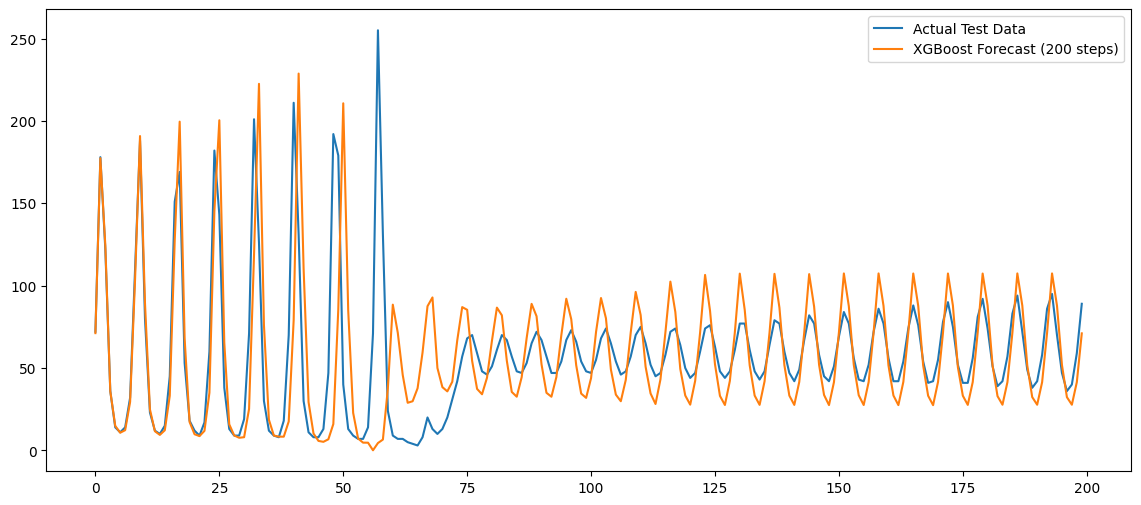

In [69]:
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
plt.figure(figsize=(14, 6))
plt.plot(test, label="Actual Test Data")
plt.plot(preds_inv, label="XGBoost Forecast (200 steps)")
plt.legend()
plt.show()

In [70]:
mae = mean_absolute_error(test, preds_inv)
mse = mean_squared_error(test, preds_inv)
rmse = np.sqrt(mse)
r2 = 1 - (mse / np.var(test))
print(f"Final Test MAE: {mae:.5f}, MSE: {mse:.5f}, RMSE: {rmse:.5f}, R²: {r2:.5f}")

Final Test MAE: 21.10139, MSE: 1414.88389, RMSE: 37.61494, R²: 0.15182


In [30]:
# import numpy as np
# import scipy.io
# import xgboost as xgb

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import MinMaxScaler
# from itertools import product

# # =========================================================
# # LOAD DATA
# # =========================================================

# def load_mat_series(path):
#     mat = scipy.io.loadmat(path)
#     keys = [k for k in mat.keys() if not k.startswith("__")]
#     return np.asarray(mat[keys[0]]).ravel().astype(float)

# train = load_mat_series("Xtrain.mat")
# test  = load_mat_series("Xtest.mat")

# # =========================================================
# # SCALE
# # =========================================================

# scaler = MinMaxScaler()

# train_scaled = scaler.fit_transform(
#     train.reshape(-1,1)
# ).ravel()

# test_scaled = scaler.transform(
#     test.reshape(-1,1)
# ).ravel()

# # =========================================================
# # CREATE LAGS
# # =========================================================

# def create_lag(series, window):

#     X = []
#     y = []

#     for i in range(len(series) - window):

#         X.append(series[i:i+window])
#         y.append(series[i+window])

#     return np.array(X), np.array(y)

# # =========================================================
# # HYPERPARAMETER GRID
# # =========================================================

# param_grid = {

#     "window": [5, 10, 20, 30],

#     "max_depth": [2, 3, 4, 5],

#     "learning_rate": [0.01, 0.03, 0.05],

#     "n_estimators": [200, 400, 600],

#     "subsample": [0.8, 1.0],

#     "colsample_bytree": [0.8, 1.0],

#     "reg_alpha": [0.0, 0.1],

#     "reg_lambda": [1.0, 2.0]
# }

# # =========================================================
# # SEARCH
# # =========================================================

# best_mae = float("inf")
# best_model = None
# best_params = None

# all_results = []

# combinations = list(product(
#     param_grid["window"],
#     param_grid["max_depth"],
#     param_grid["learning_rate"],
#     param_grid["n_estimators"],
#     param_grid["subsample"],
#     param_grid["colsample_bytree"],
#     param_grid["reg_alpha"],
#     param_grid["reg_lambda"]
# ))

# print("Total combinations:", len(combinations))

# for (
#     window,
#     max_depth,
#     learning_rate,
#     n_estimators,
#     subsample,
#     colsample_bytree,
#     reg_alpha,
#     reg_lambda
# ) in combinations:

#     # ---------------------------------------------
#     # Create lagged data
#     # ---------------------------------------------

#     X, y = create_lag(train_scaled, window)

#     # ---------------------------------------------
#     # Time-series split
#     # ---------------------------------------------

#     split = int(0.8 * len(X))

#     X_train = X[:split]
#     y_train = y[:split]

#     X_val = X[split:]
#     y_val = y[split:]

#     # ---------------------------------------------
#     # Model
#     # ---------------------------------------------

#     model = xgb.XGBRegressor(

#         objective="reg:squarederror",

#         n_estimators=n_estimators,

#         learning_rate=learning_rate,

#         max_depth=max_depth,

#         subsample=subsample,

#         colsample_bytree=colsample_bytree,

#         reg_alpha=reg_alpha,

#         reg_lambda=reg_lambda,

#         random_state=42
#     )

#     # ---------------------------------------------
#     # Train
#     # ---------------------------------------------

#     model.fit(X_train, y_train)

#     # ---------------------------------------------
#     # Validation prediction
#     # ---------------------------------------------

#     val_pred = model.predict(X_val)

#     mae = mean_absolute_error(y_val, val_pred)
#     mse = mean_squared_error(y_val, val_pred)

#     all_results.append({
#         "window": window,
#         "max_depth": max_depth,
#         "learning_rate": learning_rate,
#         "n_estimators": n_estimators,
#         "subsample": subsample,
#         "colsample_bytree": colsample_bytree,
#         "reg_alpha": reg_alpha,
#         "reg_lambda": reg_lambda,
#         "mae": mae,
#         "mse": mse
#     })

#     print(
#         f"window={window} | "
#         f"depth={max_depth} | "
#         f"lr={learning_rate} | "
#         f"trees={n_estimators} | "
#         f"MAE={mae:.5f}"
#     )

#     # ---------------------------------------------
#     # Save best
#     # ---------------------------------------------

#     if mae < best_mae:

#         best_mae = mae

#         best_model = model

#         best_params = {
#             "window": window,
#             "max_depth": max_depth,
#             "learning_rate": learning_rate,
#             "n_estimators": n_estimators,
#             "subsample": subsample,
#             "colsample_bytree": colsample_bytree,
#             "reg_alpha": reg_alpha,
#             "reg_lambda": reg_lambda
#         }

# # =========================================================
# # BEST RESULT
# # =========================================================

# print("\nBEST PARAMETERS:")
# print(best_params)

# print("\nBEST VALIDATION MAE:")
# print(best_mae)

# # =========================================================
# # FINAL TRAINING
# # =========================================================

# best_window = best_params["window"]

# X_full, y_full = create_lag(train_scaled, best_window)

# final_model = xgb.XGBRegressor(

#     objective="reg:squarederror",

#     n_estimators=best_params["n_estimators"],

#     learning_rate=best_params["learning_rate"],

#     max_depth=best_params["max_depth"],

#     subsample=best_params["subsample"],

#     colsample_bytree=best_params["colsample_bytree"],

#     reg_alpha=best_params["reg_alpha"],

#     reg_lambda=best_params["reg_lambda"],

#     random_state=42
# )

# final_model.fit(X_full, y_full)

# # =========================================================
# # TEST EVALUATION
# # =========================================================

# test_X, test_y = create_lag(test_scaled, best_window)

# test_pred = final_model.predict(test_X)

# # inverse transform
# test_pred_inv = scaler.inverse_transform(
#     test_pred.reshape(-1,1)
# ).ravel()

# test_y_inv = scaler.inverse_transform(
#     test_y.reshape(-1,1)
# ).ravel()

# mae = mean_absolute_error(test_y_inv, test_pred_inv)
# mse = mean_squared_error(test_y_inv, test_pred_inv)

# print("\nFINAL TEST RESULTS")
# print("MAE:", mae)
# print("MSE:", mse)

{'window': 10, 'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}